# Renewable Energy Integration – OpenModelica Frequency Metrics (Q1-ready, fixed)
This notebook:
- Loads your PV/Wind/Load time-series from `data.zip`
- Builds renewable-driven disturbance events (worst RES drop)
- Runs OpenModelica reduced-order frequency model for Baseline vs Droop vs Droop+FFR
- Computes RoCoF, Nadir, Settling time and exports CSV + figures

**Fix included:** avoids `ThesisFreqCases.DroopFFRCase` build failures by running the FFR case using `ThesisFreqCases.DroopCase` with parameter overrides.


In [23]:

import os, re, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from OMPython import OMCSessionZMQ

# ===== EDIT THESE PATHS (Windows) =====
BASE_DIR = r"C:\Users\ADMIN\Desktop\ms-project"
DATA_ZIP_PATH = r"C:\Users\ADMIN\Desktop\data.zip"
# =====================================

os.makedirs(BASE_DIR, exist_ok=True)
THESIS_MO_PATH = os.path.join(BASE_DIR, "ThesisFreqCases_FIXED.mo")

print("BASE_DIR:", BASE_DIR)
print("DATA_ZIP_PATH exists:", os.path.exists(DATA_ZIP_PATH))
print("THESIS_MO_PATH:", THESIS_MO_PATH)


BASE_DIR: C:\Users\ADMIN\Desktop\ms-project
DATA_ZIP_PATH exists: True
THESIS_MO_PATH: C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases_FIXED.mo


In [24]:

# --- Write/overwrite ThesisFreqCases.mo (stable initialization + droop/FFR different time constants)
modelica_code = r'''
within ;
package ThesisFreqCases
  partial model BaseFreqCase
    parameter Real f0 = 50 "Nominal frequency (Hz)";
    parameter Real H = 4.0 "Virtual inertia constant (s)";
    parameter Real D = 1.0 "Damping coefficient (pu/Hz)";
    parameter Real R = 0.06 "Droop gain (Hz/pu)";
    parameter Real deadband = 0.02 "Deadband (Hz)";

    // Make FFR faster than droop (to show benefit)
    parameter Real T_droop = 0.30 "Droop measurement/actuation time constant (s)";
    parameter Real T_ffr   = 0.05 "FFR time constant (s)";

    parameter Real PmaxDroop = 0.20 "Droop support cap (pu)";
    parameter Real PmaxFFR = 0.15 "FFR support cap (pu)";
    parameter Real PmaxTotal = 0.30 "Total support cap (pu)";
    parameter Real ffrGain = 1.00 "FFR gain (pu/Hz)";
    parameter Real ffrDuration = 2.0 "FFR duration after event (s)";

    parameter Real tEvent = 1.0 "Disturbance start time (s)";
    parameter Real dPstep = -0.10 "Disturbance (pu), negative = deficit";

    // Fix initial conditions to remove warning
    Real df(start=0, fixed=true) "Frequency deviation (Hz)";
    Real fHz "Frequency (Hz)";
    Real rocofHzps "RoCoF (Hz/s)";

    Real Pdist "Disturbance power (pu)";
    Real Pdroop "Droop support (pu)";
    Real Pffr "FFR support (pu)";
    Real Psupport "Total support (pu)";

  protected
    Real df_droop(start=0, fixed=true);
    Real df_ffr(start=0, fixed=true);
    Real Pdroop_raw;
    Real Pffr_raw;

  equation
    // Disturbance step
    Pdist = if time < tEvent then 0 else dPstep;

    // Filtered measurements
    der(df_droop) = (df - df_droop)/T_droop;
    der(df_ffr)   = (df - df_ffr)/T_ffr;

    // Droop
    Pdroop_raw = if noEvent(abs(df_droop) <= deadband) then 0 else -df_droop / R;
    Pdroop = min(max(Pdroop_raw, -PmaxDroop), PmaxDroop);

    // FFR
    Pffr_raw = if noEvent(time < tEvent or time > tEvent + ffrDuration or abs(df_ffr) <= deadband) then 0 else -ffrGain * df_ffr;
    Pffr = min(max(Pffr_raw, -PmaxFFR), PmaxFFR);

    Psupport = min(max(Pdroop + Pffr, -PmaxTotal), PmaxTotal);

    // Dynamics
    der(df) = (f0 / (2 * H)) * (Pdist + Psupport - D * df);

    // Outputs
    fHz = f0 + df;
    rocofHzps = der(fHz);

    annotation(experiment(StopTime=12, Interval=0.01));
  end BaseFreqCase;

  model BaseCase
    extends BaseFreqCase(
      PmaxDroop=0.0, PmaxFFR=0.0, PmaxTotal=0.0,
      ffrGain=0.0, ffrDuration=0.0
    );
    annotation(experiment(StopTime=12, Interval=0.01));
  end BaseCase;

  model DroopCase
    extends BaseFreqCase(
      PmaxDroop=0.20, PmaxFFR=0.0, PmaxTotal=0.20,
      ffrGain=0.0, ffrDuration=0.0
    );
    annotation(experiment(StopTime=12, Interval=0.01));
  end DroopCase;

  // DroopFFRCase remains defined for readability, but notebook does NOT depend on it compiling.
  model DroopFFRCase
    extends BaseFreqCase(
      PmaxDroop=0.20, PmaxFFR=0.15, PmaxTotal=0.30,
      ffrGain=1.0, ffrDuration=2.0
    );
    annotation(experiment(StopTime=12, Interval=0.01));
  end DroopFFRCase;

end ThesisFreqCases;
'''
with open(THESIS_MO_PATH, "w", encoding="utf-8") as f:
    f.write(modelica_code)

print("Wrote:", THESIS_MO_PATH, "| Exists:", os.path.exists(THESIS_MO_PATH))


Wrote: C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases_FIXED.mo | Exists: True


In [25]:

# --- Start OpenModelica and load model
omc = OMCSessionZMQ()

print("OpenModelica version:", omc.sendExpression("getVersion()"))
print("loadModel(Modelica):", omc.sendExpression("loadModel(Modelica)"))
print("cd(BASE_DIR):", omc.sendExpression(f'cd("{BASE_DIR}")'))
print("loadFile(ThesisFreqCases.mo):", omc.sendExpression(f'loadFile("{THESIS_MO_PATH}")'))

print("isModel(BaseCase):", omc.sendExpression("isModel(ThesisFreqCases.BaseCase)"))
print("isModel(DroopCase):", omc.sendExpression("isModel(ThesisFreqCases.DroopCase)"))
print("isModel(DroopFFRCase):", omc.sendExpression("isModel(ThesisFreqCases.DroopFFRCase)"))


OpenModelica version: OpenModelica v1.26.2 (64-bit)
loadModel(Modelica): True


[OMC log for 'sendExpression(cd("C:\Users\ADMIN\Desktop\ms-project"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \U is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(cd("C:\Users\ADMIN\Desktop\ms-project"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \A is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(cd("C:\Users\ADMIN\Desktop\ms-project"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \D is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(cd("C:\Users\ADMIN\Desktop\ms-project"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \m is not a valid Modelica escape sequence.


cd(BASE_DIR): C:/Users/ADMIN/Desktop/ms-project


[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases_FIXED.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \U is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases_FIXED.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \A is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases_FIXED.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \D is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases_FIXED.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \m is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases_FIXED.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \T is not a valid Modelica es

loadFile(ThesisFreqCases.mo): True
isModel(BaseCase): True
isModel(DroopCase): True
isModel(DroopFFRCase): True


In [32]:

# --- Robust simulation helper (prints build errors)
def simulate_openmodelica_model(omc, model_name, stopTime=12.0, stepSize=0.01, outputFormat="csv", parameter_overrides=None):
    simflags = ""
    if parameter_overrides:
        override_str = ",".join([f"{k}={v}" for k, v in parameter_overrides.items()])
        simflags = f', simflags="-override={override_str}"'

    n_intervals = int(round(stopTime / stepSize))
    cmd = f'simulate({model_name}, stopTime={stopTime}, numberOfIntervals={n_intervals}, outputFormat="{outputFormat}"{simflags})'
    sim_out = omc.sendExpression(cmd)

    if isinstance(sim_out, dict):
        msg = sim_out.get("messages", "")
        if msg:
            print("OMC messages:\n", msg)

        res = sim_out.get("resultFile", "")
        if res and os.path.exists(res):
            return res, sim_out

        print("OpenModelica getErrorString():\n", omc.sendExpression("getErrorString()"))
        raise RuntimeError(f"Simulation failed for {model_name}. See messages above.")

    # Fallback parse if returned as string
    txt = str(sim_out)
    m = re.search(r'resultFile\\s*=\\s*\\"([^\\"]+)\\"', txt)
    if m and os.path.exists(m.group(1)):
        return m.group(1), sim_out

    print("OpenModelica getErrorString():\n", omc.sendExpression("getErrorString()"))
    raise RuntimeError(f"Could not parse resultFile for {model_name}. Raw: {txt}")


def load_thesis_frequency(result_csv):
    df = pd.read_csv(result_csv)
    for c in ["time", "fHz", "rocofHzps"]:
        if c not in df.columns:
            raise RuntimeError(f"Missing '{c}' in {result_csv}. Columns: {df.columns.tolist()[:25]}")
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["time", "fHz"]).sort_values("time")
    df = df.drop_duplicates(subset=["time"], keep="first").reset_index(drop=True)

    return df["time"].values, df["fHz"].values, df["rocofHzps"].values

'''
def compute_frequency_metrics(t, f_hz, rocof_trace, eps=0.01):
    rocof = float(np.nanmax(np.abs(rocof_trace)))
    nadir = float(np.nanmin(f_hz))

    f_final = float(f_hz[-1])
    within = np.abs(f_hz - f_final) <= eps
    settling = np.nan
    for i in range(len(t)):
        if within[i] and np.all(within[i:]):
            settling = float(t[i])
            break
    return rocof, nadir, settling
'''
import numpy as np

def compute_frequency_metrics(t, f_hz, rocof_trace, eps=0.01, tEvent=1.0, window=0.2):
    """
    Returns:
      rocof_fall (Hz/s): magnitude of most negative df/dt within [tEvent, tEvent+window]
      nadir (Hz)
      settling (s)
    """
    t = np.asarray(t, dtype=float)
    f = np.asarray(f_hz, dtype=float)

    # finite-difference slope df/dt
    dfdt = np.diff(f) / np.diff(t)
    tmid = 0.5 * (t[1:] + t[:-1])

    # focus RoCoF on the first window after the event
    mask = (tmid >= tEvent) & (tmid <= tEvent + window)
    if np.any(mask):
        rocof_fall = float(abs(np.min(dfdt[mask])))   # falling RoCoF (magnitude)
    else:
        rocof_fall = float(abs(np.min(dfdt)))         # fallback

    # nadir
    nadir = float(np.min(f))

    # settling time
    f_final = float(f[-1])
    within = np.abs(f - f_final) <= eps
    settling = np.nan
    for i in range(len(t)):
        if within[i] and np.all(within[i:]):
            settling = float(t[i])
            break

    return rocof_fall, nadir, settling

In [33]:

# --- Load your time-series dataset from data.zip (stage3_timeseries_summary.csv)
with zipfile.ZipFile(DATA_ZIP_PATH, "r") as z:
    target = "data/stage3_timeseries/stage3_timeseries_summary.csv"
    with z.open(target) as f:
        ts_df = pd.read_csv(f)

ts_df.columns = [c.strip() for c in ts_df.columns]
for c in ["hour", "P_load_scaled_MW", "P_pv_MW", "P_wind_MW"]:
    ts_df[c] = pd.to_numeric(ts_df[c], errors="coerce")

ts_df = ts_df.dropna(subset=["hour", "P_load_scaled_MW", "P_pv_MW", "P_wind_MW"]).copy()
ts_df["P_res_MW"] = ts_df["P_pv_MW"] + ts_df["P_wind_MW"]
ts_df["P_net_MW"] = ts_df["P_load_scaled_MW"] - ts_df["P_res_MW"]
ts_df["dP_res_MW"] = ts_df["P_res_MW"].diff()

S_base_MW = float(ts_df["P_load_scaled_MW"].max())
print("S_base_MW:", S_base_MW)
display(ts_df.head())


S_base_MW: 2.0066470101039418


,hour,load_scale,pv_availability,wind_availability,P_load_scaled_MW,P_pv_MW,P_wind_MW,Vmin_pu,Vmax_pu,max_line_loading_pct,max_line_name,losses_MW,P_res_MW,P_net_MW,dP_res_MW
0,0,0.512236,0.0,0.761803,1.028229,0.0,0.176244,0.994817,1.049409,8.485616,L_2_3,NaN,0.176244,0.851985,NaN
1,1,0.500343,0.0,0.786716,1.004355,0.0,0.177782,0.994953,1.050001,8.558682,L_2_3,NaN,0.177782,0.826573,0.001538
2,2,0.505463,0.0,0.798904,1.014634,0.0,0.182384,0.994895,1.049865,8.548889,L_2_3,NaN,0.182384,0.832250,0.004602
3,3,0.527248,0.0,0.797538,1.058364,0.0,0.189919,0.994648,1.049013,8.458898,L_2_3,NaN,0.189919,0.868445,0.007535
4,4,0.564214,0.0,0.782709,1.132566,0.0,0.199456,0.994228,1.047490,8.298855,L_2_3,NaN,0.199456,0.933110,0.009537


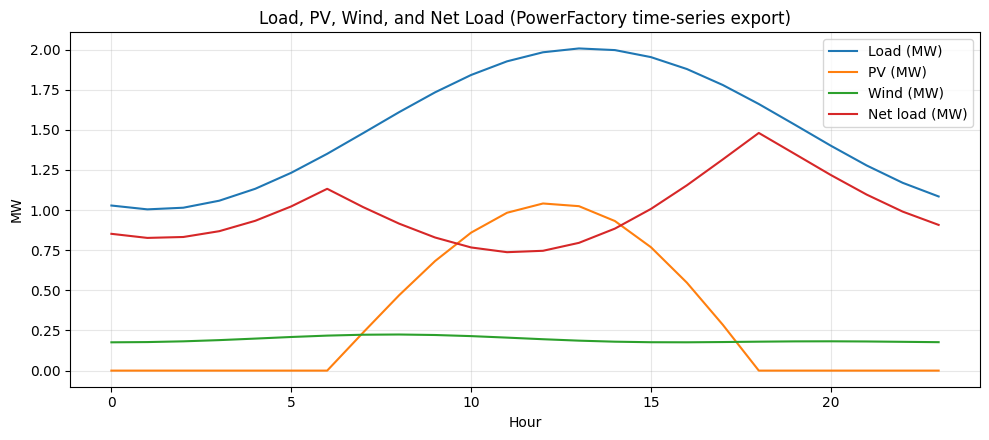

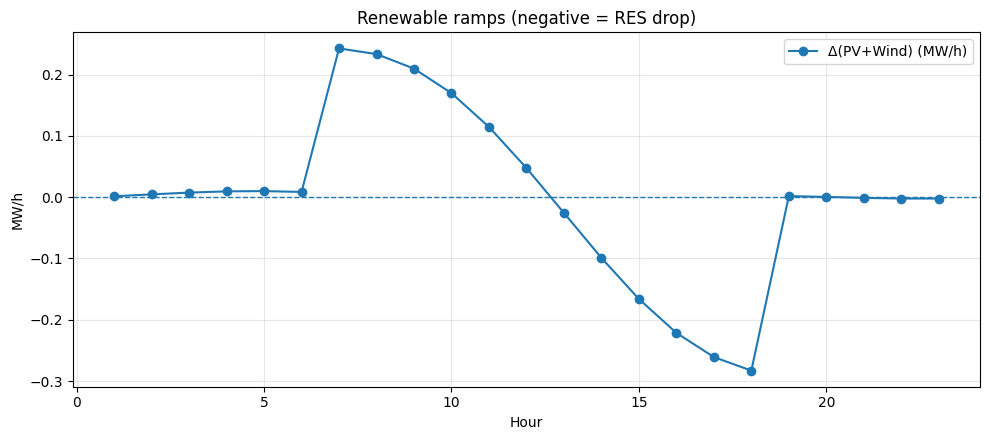

In [34]:

# --- Plot PV/Wind/Load/Net-load (paper figure)
plt.figure(figsize=(10,4.5))
plt.plot(ts_df["hour"], ts_df["P_load_scaled_MW"], label="Load (MW)")
plt.plot(ts_df["hour"], ts_df["P_pv_MW"], label="PV (MW)")
plt.plot(ts_df["hour"], ts_df["P_wind_MW"], label="Wind (MW)")
plt.plot(ts_df["hour"], ts_df["P_net_MW"], label="Net load (MW)")
plt.xlabel("Hour"); plt.ylabel("MW")
plt.title("Load, PV, Wind, and Net Load (PowerFactory time-series export)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "timeseries_load_pv_wind_netload.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10,4.5))
plt.plot(ts_df["hour"], ts_df["dP_res_MW"], marker="o", label="Δ(PV+Wind) (MW/h)")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Hour"); plt.ylabel("MW/h")
plt.title("Renewable ramps (negative = RES drop)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "timeseries_res_ramps.png"), dpi=300, bbox_inches="tight")
plt.show()


In [35]:

# --- Build renewable-driven disturbance events per penetration (0/10/25/50/75)
penetrations = [0, 10, 25, 50, 75]
rows = []

for pen in penetrations:
    scale = pen/100.0
    tmp = ts_df.copy()
    tmp["P_res_pen_MW"] = scale * (tmp["P_pv_MW"] + tmp["P_wind_MW"])
    tmp["dP_res_pen_MW"] = tmp["P_res_pen_MW"].diff()

    # Worst RES drop = most negative ΔRES
    idx = tmp["dP_res_pen_MW"].idxmin()
    evt = tmp.loc[idx]

    dP_deficit_MW = -float(evt["dP_res_pen_MW"])  # positive magnitude
    dPstep_pu = -(dP_deficit_MW / S_base_MW)      # negative in model convention

    rows.append([pen, float(evt["hour"]), float(evt["dP_res_pen_MW"]), dPstep_pu])

pen_event_df = pd.DataFrame(rows, columns=[
    "Penetration (%)", "Hour (worst RES drop)", "Worst ΔRES (MW/h)", "dPstep (pu)"
])

display(pen_event_df)
pen_event_df.to_csv(os.path.join(BASE_DIR, "penetration_event_mapping_res_drop.csv"), index=False)


,Penetration (%),Hour (worst RES drop),Worst ΔRES (MW/h),dPstep (pu)
0,0,1.0,0.000000,0.000000
1,10,18.0,-0.028303,-0.014105
2,25,18.0,-0.070757,-0.035262
3,50,18.0,-0.141515,-0.070523
4,75,18.0,-0.212272,-0.105785


Using 75% RES event dPstep: -0.10578458987531997
OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.



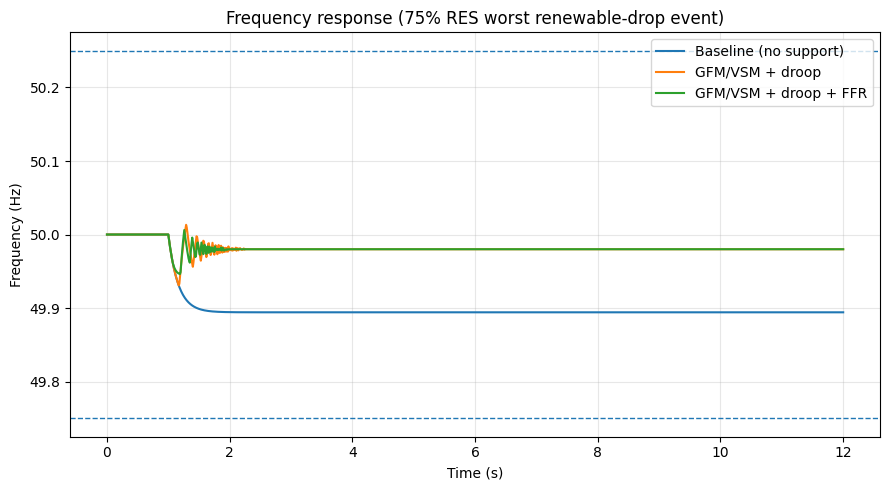

Saved: C:\Users\ADMIN\Desktop\ms-project\freq_cases_75pct_res_event.png


,Case,Model,Overrides,RoCoF (Hz/s),Nadir (Hz),Settling time (s),Result CSV
0,Baseline (no support),ThesisFreqCases.BaseCase,"{'dPstep': -0.10578458987531997, 'tEvent': 1.0}",0.640925,49.894215,1.38,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
1,GFM/VSM + droop,ThesisFreqCases.DroopCase,"{'dPstep': -0.10578458987531997, 'tEvent': 1.0}",0.640925,49.930774,1.63,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
2,GFM/VSM + droop + FFR,ThesisFreqCases.DroopCase,"{'dPstep': -0.10578458987531997, 'tEvent': 1.0...",0.640925,49.946282,1.45,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...


In [36]:

# --- Run 75% penetration event: Baseline vs Droop vs Droop+FFR (FFR case uses DroopCase + overrides)
dPstep_75 = float(pen_event_df.loc[pen_event_df["Penetration (%)"]==75, "dPstep (pu)"].iloc[0])
print("Using 75% RES event dPstep:", dPstep_75)

cases = [
    ("Baseline (no support)", "ThesisFreqCases.BaseCase", {"dPstep": dPstep_75, "tEvent": 1.0}),
    ("GFM/VSM + droop", "ThesisFreqCases.DroopCase", {"dPstep": dPstep_75, "tEvent": 1.0}),
    # Avoid DroopFFRCase build issues by using DroopCase with FFR parameters overridden
    ("GFM/VSM + droop + FFR", "ThesisFreqCases.DroopCase", {
        "dPstep": dPstep_75, "tEvent": 1.0,
        "PmaxFFR": 0.15, "PmaxTotal": 0.30, "ffrGain": 1.0, "ffrDuration": 2.0,
        "T_ffr": 0.05, "T_droop": 0.30
    }),
]

rows = []
plt.figure(figsize=(9,5))

for label, model, overrides in cases:
    res_csv, _ = simulate_openmodelica_model(omc, model, stopTime=12.0, stepSize=0.01, parameter_overrides=overrides)
    t, f_hz, rocof_trace = load_thesis_frequency(res_csv)
    rocof, nadir, settling = compute_frequency_metrics(t, f_hz, rocof_trace, eps=0.01)
    rows.append([label, model, overrides, rocof, nadir, settling, res_csv])
    plt.plot(t, f_hz, label=label)

plt.axhline(49.75, linestyle="--", linewidth=1)
plt.axhline(50.25, linestyle="--", linewidth=1)
plt.xlabel("Time (s)"); plt.ylabel("Frequency (Hz)")
plt.title("Frequency response (75% RES worst renewable-drop event)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
outpng = os.path.join(BASE_DIR, "freq_cases_75pct_res_event.png")
plt.savefig(outpng, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", outpng)

cases_75_df = pd.DataFrame(rows, columns=[
    "Case","Model","Overrides","RoCoF (Hz/s)","Nadir (Hz)","Settling time (s)","Result CSV"
])
display(cases_75_df)
cases_75_df.to_csv(os.path.join(BASE_DIR, "dynamic_metrics_cases_75pct_res_event.csv"), index=False)


OMC messages:
 LOG_STDOUT        | warning | You are overriding dPstep with a small value or zero.
|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

OMC messages:
 LOG_SUCCESS       | info    | The initializati

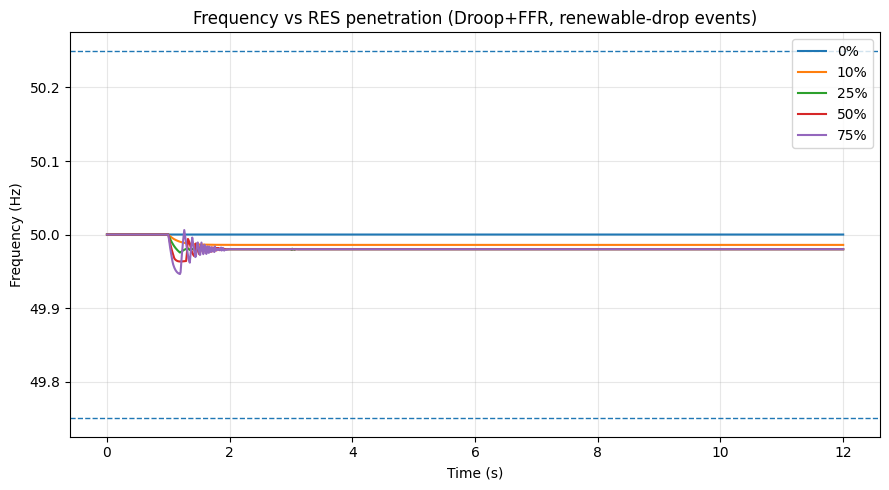

Saved: C:\Users\ADMIN\Desktop\ms-project\freq_vs_penetration_droopFFR.png


,Penetration (%),dPstep (pu),RoCoF (Hz/s),Nadir (Hz),Settling time (s),Result CSV
0,0,0.000000,0.000000,50.000000,0.00,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
1,10,-0.014105,0.085460,49.985895,1.06,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
2,25,-0.035262,0.213647,49.975493,1.06,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
3,50,-0.070523,0.427294,49.963305,1.34,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
4,75,-0.105785,0.640925,49.946282,1.45,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...


In [37]:

# --- Penetration study (fast): run only Droop+FFR case for 0–75%
rows = []
plt.figure(figsize=(9,5))

for _, r in pen_event_df.iterrows():
    pen = int(r["Penetration (%)"])
    dPstep = float(r["dPstep (pu)"])

    overrides = {
        "dPstep": dPstep, "tEvent": 1.0,
        "PmaxFFR": 0.15, "PmaxTotal": 0.30, "ffrGain": 1.0, "ffrDuration": 2.0,
        "T_ffr": 0.05, "T_droop": 0.30
    }

    res_csv, _ = simulate_openmodelica_model(omc, "ThesisFreqCases.DroopCase", stopTime=12.0, stepSize=0.01, parameter_overrides=overrides)
    t, f_hz, rocof_trace = load_thesis_frequency(res_csv)
    rocof, nadir, settling = compute_frequency_metrics(t, f_hz, rocof_trace, eps=0.01)

    rows.append([pen, dPstep, rocof, nadir, settling, res_csv])
    plt.plot(t, f_hz, label=f"{pen}%")

plt.axhline(49.75, linestyle="--", linewidth=1)
plt.axhline(50.25, linestyle="--", linewidth=1)
plt.xlabel("Time (s)"); plt.ylabel("Frequency (Hz)")
plt.title("Frequency vs RES penetration (Droop+FFR, renewable-drop events)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
outpng = os.path.join(BASE_DIR, "freq_vs_penetration_droopFFR.png")
plt.savefig(outpng, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", outpng)

pen_metrics_df = pd.DataFrame(rows, columns=[
    "Penetration (%)","dPstep (pu)","RoCoF (Hz/s)","Nadir (Hz)","Settling time (s)","Result CSV"
])
display(pen_metrics_df)
pen_metrics_df.to_csv(os.path.join(BASE_DIR, "dynamic_metrics_vs_penetration_droopFFR.csv"), index=False)


In [38]:
import numpy as np
import pandas as pd

def rocof_fall_in_window(t, f, t0, t1):
    t = np.asarray(t); f = np.asarray(f)
    dfdt = np.diff(f) / np.diff(t)
    tmid = 0.5*(t[1:] + t[:-1])
    mask = (tmid >= t0) & (tmid <= t1)
    if np.any(mask):
        return float(abs(np.min(dfdt[mask])))  # falling RoCoF magnitude
    return float(abs(np.min(dfdt)))

def settling_time(t, f, eps=0.01):
    f_final = float(f[-1])
    within = np.abs(f - f_final) <= eps
    for i in range(len(t)):
        if within[i] and np.all(within[i:]):
            return float(t[i])
    return np.nan

# --- build a proper case list (FFR enabled via overrides) ---
dPstep_75 = float(pen_event_df.loc[pen_event_df["Penetration (%)"]==75, "dPstep (pu)"].iloc[0])
tEvent = 1.0

CASE_SPECS = [
    ("Baseline (no support)", "ThesisFreqCases.BaseCase",
     {"dPstep": dPstep_75, "tEvent": tEvent}),

    ("GFM/VSM + droop", "ThesisFreqCases.DroopCase",
     {"dPstep": dPstep_75, "tEvent": tEvent,
      "PmaxDroop": 0.20, "PmaxTotal": 0.20}),

    # droop+FFR using DroopCase + overrides (avoids build issues)
    ("GFM/VSM + droop + FFR", "ThesisFreqCases.DroopCase",
     {"dPstep": dPstep_75, "tEvent": tEvent,
      "PmaxDroop": 0.20, "PmaxFFR": 0.15, "PmaxTotal": 0.30,
      "ffrGain": 1.0, "ffrDuration": 2.0,
      "T_droop": 0.30, "T_ffr": 0.05})
]

rows = []
for case_name, model_name, overrides in CASE_SPECS:
    res_csv, _ = simulate_openmodelica_model(
        omc, model_name, stopTime=15.0, stepSize=0.01,
        parameter_overrides=overrides
    )

    t, f_hz, rocof_trace = load_thesis_frequency(res_csv)

    rocof_0p  = rocof_fall_in_window(t, f_hz, tEvent, tEvent+0.2)      # initial
    rocof_eff = rocof_fall_in_window(t, f_hz, tEvent+0.1, tEvent+1.0)  # after control begins

    nadir = float(np.min(f_hz))
    st = settling_time(t, f_hz, eps=0.01)

    rows.append([case_name, model_name, str(overrides), rocof_0p, rocof_eff, nadir, st, res_csv])

cases_75_df = pd.DataFrame(rows, columns=[
    "Case","Model","Overrides","RoCoF_0+ (Hz/s)","RoCoF_eff (Hz/s)","Nadir (Hz)","Settling time (s)","Result CSV"
])
display(cases_75_df)

OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.



,Case,Model,Overrides,RoCoF_0+ (Hz/s),RoCoF_eff (Hz/s),Nadir (Hz),Settling time (s),Result CSV
0,Baseline (no support),ThesisFreqCases.BaseCase,"{'dPstep': -0.10578458987531997, 'tEvent': 1.0}",0.640925,0.343058,49.894215,1.38,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
1,GFM/VSM + droop,ThesisFreqCases.DroopCase,"{'dPstep': -0.10578458987531997, 'tEvent': 1.0...",0.640925,0.700578,49.930774,1.63,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
2,GFM/VSM + droop + FFR,ThesisFreqCases.DroopCase,"{'dPstep': -0.10578458987531997, 'tEvent': 1.0...",0.640925,0.644196,49.946282,1.45,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...


## Optional sensitivity study (small grid for fast runtime)
Set `RUN_SENSITIVITY=False` if you want the notebook to run faster.


In [14]:

RUN_SENSITIVITY = False

if RUN_SENSITIVITY:
    Hs  = [2.0, 4.0, 6.0]
    Rs  = [0.05, 0.06]
    DBs = [0.01, 0.02]

    dPstep = float(pen_event_df.loc[pen_event_df["Penetration (%)"]==75, "dPstep (pu)"].iloc[0])

    sens_rows = []
    for H in Hs:
        for R in Rs:
            for db in DBs:
                overrides = {
                    "H":H, "R":R, "deadband":db,
                    "dPstep":dPstep, "tEvent":1.0,
                    "PmaxFFR":0.15, "PmaxTotal":0.30, "ffrGain":1.0, "ffrDuration":2.0,
                    "T_ffr":0.05, "T_droop":0.30
                }
                res_csv, _ = simulate_openmodelica_model(omc, "ThesisFreqCases.DroopCase", stopTime=12.0, stepSize=0.01, parameter_overrides=overrides)
                t, f_hz, rocof_trace = load_thesis_frequency(res_csv)
                rocof, nadir, settling = compute_frequency_metrics(t, f_hz, rocof_trace, eps=0.01)
                sens_rows.append([H, R, db, rocof, nadir, settling])

    sens_df = pd.DataFrame(sens_rows, columns=[
        "H (s)","Droop R (Hz/pu)","Deadband (Hz)","RoCoF (Hz/s)","Nadir (Hz)","Settling time (s)"
    ])
    display(sens_df)
    sens_df.to_csv(os.path.join(BASE_DIR, "dynamic_metrics_sensitivity_smallgrid.csv"), index=False)


In [15]:

# --- Save run metadata for reproducibility
info = [
    f"OpenModelica version: {omc.sendExpression('getVersion()')}",
    f"BASE_DIR: {BASE_DIR}",
    f"DATA_ZIP_PATH: {DATA_ZIP_PATH}",
    f"S_base_MW: {S_base_MW}",
    "Event selection: worst renewable-drop event (min Δ(PV+Wind)) per penetration.",
    "Frequency model: reduced-order swing-like dynamics with droop and fast frequency response (FFR).",
    "Implementation: OpenModelica simulation + Python metric extraction (RoCoF, nadir, settling).",
    "FFR case implemented via overrides on ThesisFreqCases.DroopCase to avoid build issues with DroopFFRCase."
]
with open(os.path.join(BASE_DIR, "run_info.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(info))

print("Saved:", os.path.join(BASE_DIR, "run_info.txt"))


Saved: C:\Users\ADMIN\Desktop\ms-project\run_info.txt
